In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
X,y=np.arange(10).reshape((5,2)),range(5)
X

array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7],
       [8, 9]])

In [2]:
list(y)

[0, 1, 2, 3, 4]

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [6]:
X_train

array([[4, 5],
       [0, 1],
       [6, 7]])

In [7]:
y_train


[2, 0, 3]

In [8]:
X_test

array([[2, 3],
       [8, 9]])

In [9]:
y_test

[1, 4]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [11]:
X_train,X_test,y_train,y_test

(array([[4, 5],
        [0, 1],
        [6, 7]]),
 array([[2, 3],
        [8, 9]]),
 [2, 0, 3],
 [1, 4])

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33)

In [13]:
X_train,X_test,y_train,y_test

(array([[0, 1],
        [8, 9],
        [6, 7]]),
 array([[4, 5],
        [2, 3]]),
 [0, 4, 3],
 [2, 1])

## implementation of logistic regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.linear_model import LogisticRegression

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
from sklearn.datasets import load_breast_cancer

In [7]:
## step1:load dataset
data=load_breast_cancer()
X,y=data.data, data.target
print("Classes:",data.target_names)

Classes: ['malignant' 'benign']


In [8]:
#load breast_cancer and convert into dataframe
df=pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [9]:
#print(data.data.shape)
print(X.shape)

(569, 30)


In [10]:
print(data.target.shape)

(569,)


In [11]:
print("Features:", data.feature_names)

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [12]:
#step2: Train-test-split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
#step3: feature scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

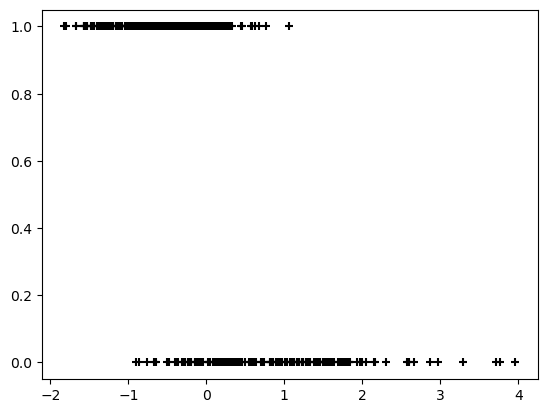

In [14]:
plt.scatter(X_train[:,0],y_train,marker='+',color='black')

In [15]:
#step4: build & train model
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
#predict
y_pred=model.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [17]:
y_pred_prob=model.predict_proba(X_test)[:,1]
y_pred_prob

array([8.86409750e-01, 9.00936206e-06, 3.07909541e-03, 9.99489866e-01,
       9.99939361e-01, 9.48087773e-11, 1.53672648e-09, 3.49030633e-02,
       6.20657860e-01, 9.99240597e-01, 9.50128217e-01, 1.24071210e-02,
       9.93926181e-01, 1.43930883e-01, 9.98378244e-01, 7.40182295e-04,
       9.98147541e-01, 9.99988834e-01, 9.99999182e-01, 1.11701472e-06,
       9.15836610e-01, 9.90252217e-01, 4.33732393e-09, 9.99921081e-01,
       9.98861257e-01, 9.99415413e-01, 9.98925555e-01, 9.94024817e-01,
       9.97146883e-01, 8.18296669e-06, 9.99482590e-01, 9.99851240e-01,
       9.97839056e-01, 9.94505862e-01, 9.99859294e-01, 9.97576657e-01,
       5.75840151e-02, 9.97101296e-01, 8.87859084e-05, 9.51863624e-01,
       9.99928757e-01, 4.06608387e-04, 9.97533594e-01, 9.99036115e-01,
       9.80010795e-01, 9.28445266e-01, 9.99601428e-01, 9.99509374e-01,
       9.69530199e-01, 9.99385984e-01, 1.20346382e-04, 5.31315374e-08,
       6.91788480e-01, 9.86770623e-01, 9.99972637e-01, 9.90454756e-01,
      

In [18]:
#for checking accuracy level of model
from sklearn.metrics import(accuracy_score,confusion_matrix,classification_report)

In [19]:
model.score(X_test,y_test)

0.9736842105263158

In [20]:
print(f"\nAccuracy:{accuracy_score(y_test,y_pred):.4f}")


Accuracy:0.9737


In [21]:
print("\nConfusion matrix:")
print(confusion_matrix(y_test,y_pred))
print("\nClassification report:")
print(classification_report(y_test,y_pred))


Confusion matrix:
[[41  2]
 [ 1 70]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



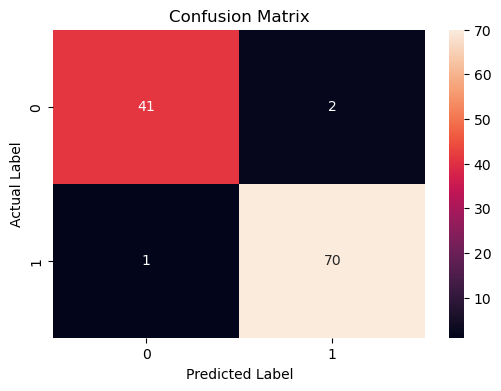

In [22]:
# Compute confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [25]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr     = lr
        self.epochs = epochs
        self.weights = None
        self.bias    = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias    = 0
        self.losses  = []

        for _ in range(self.epochs):
            # Forward pass
            z    = X @ self.weights + self.bias
            yhat = self.sigmoid(z)

            # Log loss
            loss = -np.mean(y*np.log(yhat+1e-8) +
                           (1-y)*np.log(1-yhat+1e-8))
            self.losses.append(loss)

            # Gradients
            dw = (X.T @ (yhat - y)) / m
            db = np.mean(yhat - y)

            # Gradient Descent Update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Example usage:
# model = LogisticRegressionScratch(lr=0.01, epochs=500)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# y_pred